1. Instalaciones

In [ ]:
"""
import subprocess, sys

pkgs = [
    "transformers>=4.49.0",
    "accelerate>=0.26.0",
    "Pillow",
    "pandas",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "tqdm",
    "num2words",      # requerido por SmolVLM processor
    "qwen-vl-utils",  # requerido por Qwen2.5-VL
]

for pkg in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("Dependencias listas")
"""

Dependencias listas


2. Imports

In [2]:
import os
import json
import time
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn.functional as F
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device  : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device  : cuda
GPU     : NVIDIA GeForce GTX 1050 Ti
VRAM    : 4.3 GB


3. Rutas 

In [3]:
def find_project_root() -> Path:
    current = Path(os.getcwd()).resolve()
    for candidate in [current] + list(current.parents):
        if (candidate / "data" / "raw").exists() and \
           (candidate / "data" / "processed").exists():
            return candidate
    for candidate in [current] + list(current.parents):
        if "Funeraria_Inventario_Inteligente" in candidate.parts:
            return candidate
    return current

PROJECT_ROOT = find_project_root()

# PROJECT_ROOT = Path("/ruta/absoluta/a/Funeraria_Inventario_Inteligente")

RAW_DIR     = PROJECT_ROOT / "data" / "raw"
CROPS_DIR   = PROJECT_ROOT / "data" / "processed" / "dataset" / "crops"
RESULTS_DIR = PROJECT_ROOT / "results" / "model_comparison"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raiz del proyecto : {PROJECT_ROOT}")
print()
for path, label in [(RAW_DIR, "data/raw"), (CROPS_DIR, "crops"), (RESULTS_DIR, "results")]:
    ok = path.exists()
    print(f"  {'OK' if ok else 'NO ENCONTRADO':>14}  {path}")

if RAW_DIR.exists():
    raw_files = sorted(RAW_DIR.iterdir())
    print(f"\nContenido de raw/ ({len(raw_files)} archivos):")
    for f in raw_files[:10]:
        print(f"  {f.name}")

if CROPS_DIR.exists():
    crop_files_all = sorted(CROPS_DIR.glob("*.png"))
    print(f"\nPrimeros crops ({len(crop_files_all)} total):")
    for f in crop_files_all[:8]:
        print(f"  {f.name}")

Raiz del proyecto : C:\Users\fabri\OneDrive\Desktop\UPAO\Funeraria_Inventario_Inteligente

              OK  C:\Users\fabri\OneDrive\Desktop\UPAO\Funeraria_Inventario_Inteligente\data\raw
              OK  C:\Users\fabri\OneDrive\Desktop\UPAO\Funeraria_Inventario_Inteligente\data\processed\dataset\crops
              OK  C:\Users\fabri\OneDrive\Desktop\UPAO\Funeraria_Inventario_Inteligente\results\model_comparison

Contenido de raw/ (51 archivos):
  0.png
  1.png
  10.png
  12.png
  13.png
  14.png
  16.png
  17.png
  19.png
  2.png

Primeros crops (779 total):
  10_ataud_011.png
  10_capilla_012.png
  10_cargadores_013.png
  10_carroza_008.png
  10_carroza_flores_009.png
  10_contratante_002.png
  10_direccion_003.png
  10_dni_contratante_007.png


4. Explorar imágenes disponibles

In [4]:
def get_available_images() -> dict:
    """
    imagen N.png  ->  crops con prefijo (N+1)_
    """
    available = {}
    for img_path in sorted(RAW_DIR.glob("*.png"),
                           key=lambda p: int(p.stem) if p.stem.isdigit() else 9999):
        if not img_path.stem.isdigit():
            continue
        n = int(img_path.stem)
        crops = sorted(CROPS_DIR.glob(f"{n+1}_*.png"))
        available[n] = {"image_path": img_path, "crops": crops}
    return available

AVAILABLE = get_available_images()

if not AVAILABLE:
    print("NO se encontraron imagenes. Verifica las rutas.")
else:
    print(f"{'N':>4}  {'Imagen':<16}  {'Crops':>6}  Primeros crops")
    print("-" * 72)
    for n, info in AVAILABLE.items():
        preview = ", ".join(p.name for p in info["crops"][:3])
        if len(info["crops"]) > 3:
            preview += " ..."
        print(f"{n:>4}  {info['image_path'].name:<16}  {len(info['crops']):>6}  {preview}")

   N  Imagen             Crops  Primeros crops
------------------------------------------------------------------------
   0  0.png                 16  1_ataud_009.png, 1_capilla_010.png, 1_cargadores_013.png ...
   1  1.png                 14  2_ataud_009.png, 2_capilla_010.png, 2_cargadores_012.png ...
   2  2.png                 12  3_ataud_009.png, 3_carroza_010.png, 3_contratante_002.png ...
   4  4.png                 18  5_ataud_009.png, 5_capilla_010.png, 5_cargadores_013.png ...
   5  5.png                 17  6_ataud_011.png, 6_capilla_012.png, 6_cargadores_014.png ...
   6  6.png                 14  7_ataud_009.png, 7_capilla_010.png, 7_cargadores_008.png ...
   7  7.png                 15  8_ataud_012.png, 8_capilla_013.png, 8_carroza_009.png ...
   8  8.png                 16  9_ataud_011.png, 9_cargadores_013.png, 9_carroza_009.png ...
   9  9.png                 15  10_ataud_011.png, 10_capilla_012.png, 10_cargadores_013.png ...
  10  10.png                16  11_ataud_0

5. CONFIGURACIÓN 

In [5]:
#  EDITA AQUI
IMAGE_NUMBERS = [0]

PROMPT = "Describe los elementos funerarios visibles en la imagen con el mayor detalle posible."


SELECTION = {}
for n in IMAGE_NUMBERS:
    if n not in AVAILABLE:
        print(f"  OMITIDA  imagen {n} — no encontrada en raw/")
    elif len(AVAILABLE[n]["crops"]) == 0:
        print(f"  OMITIDA  imagen {n} — sin crops (prefijo {n+1}_)")
    else:
        SELECTION[n] = AVAILABLE[n]
        print(f"  OK       imagen {n}.png  ->  {len(AVAILABLE[n]['crops'])} crops")

assert SELECTION, "Sin imagenes validas. Revisa IMAGE_NUMBERS."
print(f"\nTotal a evaluar: {len(SELECTION)} imagen(es)")

  OK       imagen 0.png  ->  16 crops

Total a evaluar: 1 imagen(es)


6. Vista previa

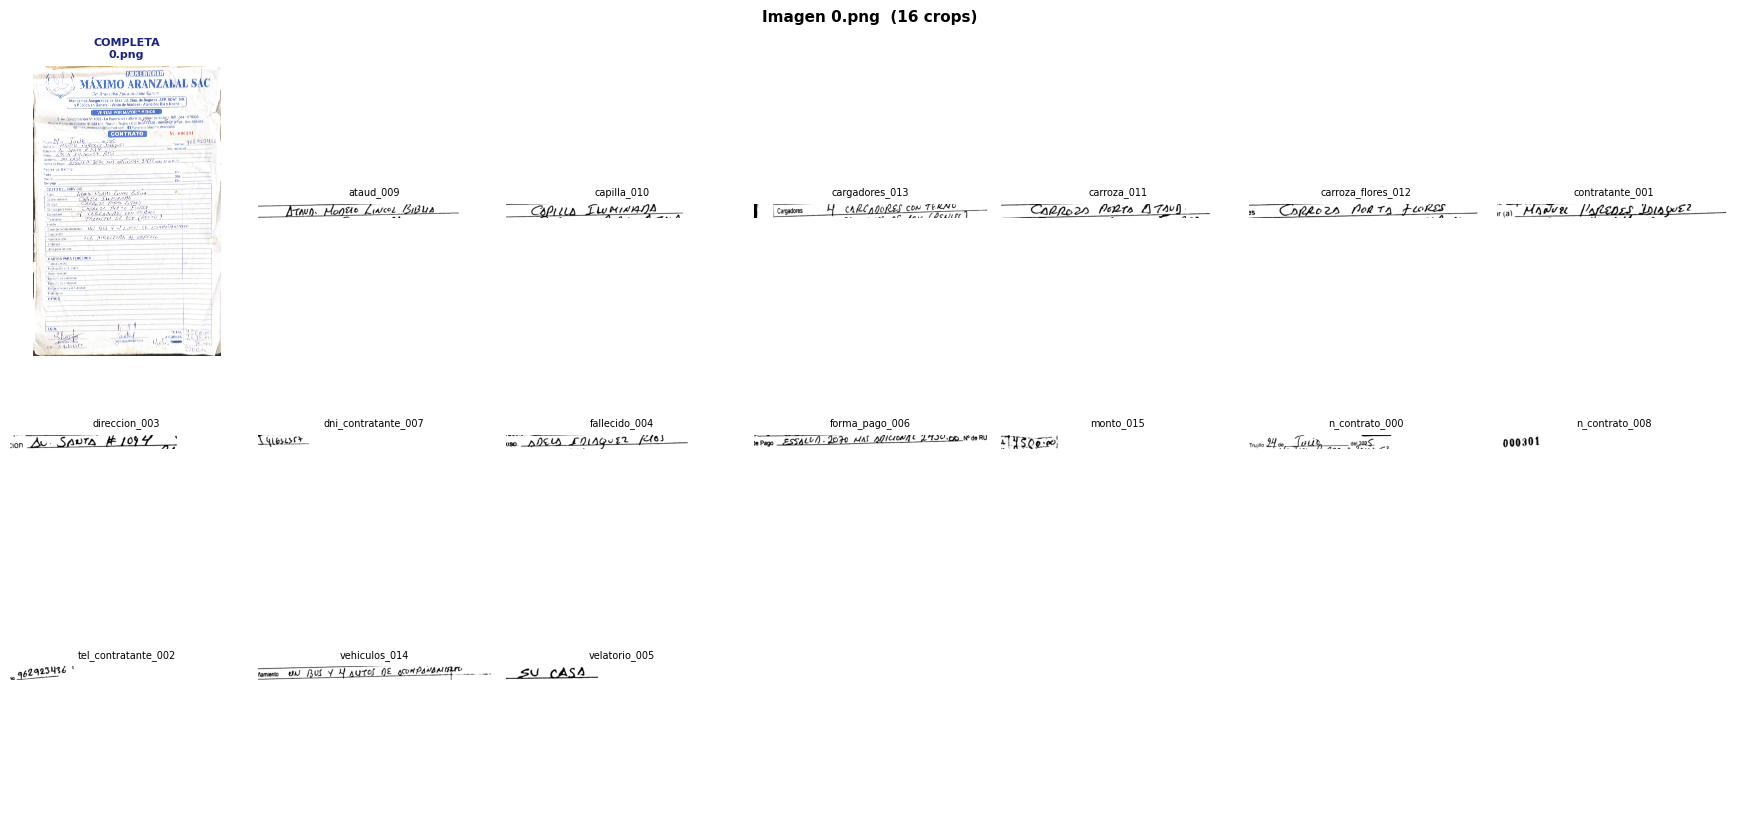

  Guardado: overview_img0.png


In [6]:
def show_image_with_crops(n, info, save_path=None):
    full_img   = Image.open(info["image_path"]).convert("RGB")
    crop_imgs  = [Image.open(p).convert("RGB") for p in info["crops"]]
    crop_names = []
    for p in info["crops"]:
        parts = p.stem.split("_", 1)
        crop_names.append(parts[1] if len(parts) > 1 else p.stem)

    total = 1 + len(crop_imgs)
    cols  = min(7, total)
    rows  = (total + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.8))
    axes = np.array(axes).flatten()

    axes[0].imshow(full_img)
    axes[0].set_title(f"COMPLETA\n{info['image_path'].name}",
                      fontsize=8, fontweight="bold", color="#1a237e")
    axes[0].axis("off")

    for i, (cimg, cname) in enumerate(zip(crop_imgs, crop_names), start=1):
        axes[i].imshow(cimg)
        axes[i].set_title(cname[:22], fontsize=7)
        axes[i].axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Imagen {n}.png  ({len(crop_imgs)} crops)", fontsize=11, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close()

for n, info in SELECTION.items():
    show_image_with_crops(n, info, save_path=RESULTS_DIR / f"overview_img{n}.png")
    print(f"  Guardado: overview_img{n}.png")

7. Modelos y funciones

In [7]:
from transformers import (
    AutoProcessor,
    AutoModelForImageTextToText,
    Qwen2_5_VLForConditionalGeneration,
)

# Modelo 1: Qwen2.5-VL-3B
# Modelo 2: SmolVLM-256M — 256M params, <1GB VRAM, nativo en transformers
MODELS = {
    "Qwen2.5-VL-3B" : "Qwen/Qwen2.5-VL-3B-Instruct",
    "SmolVLM-256M"  : "HuggingFaceTB/SmolVLM-256M-Instruct",
}

def load_model(alias: str):
    model_name = MODELS[alias]
    print(f"Cargando {alias}  ({model_name}) ...")
    t0 = time.time()

    processor = AutoProcessor.from_pretrained(model_name, trust_remote_code=True)

    if alias == "Qwen2.5-VL-3B":
        model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
            model_name,
            trust_remote_code=True,
            device_map="auto",
            torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
            output_hidden_states=True,
        )
    else:
        model = AutoModelForImageTextToText.from_pretrained(
            model_name,
            device_map="auto",
            torch_dtype=torch.bfloat16 if DEVICE == "cuda" else torch.float32,
            output_hidden_states=True,
            _attn_implementation="eager",  # flash_attention_2 opcional si tienes cuda
        )

    model.eval()
    print(f"  OK en {time.time()-t0:.1f}s")
    if DEVICE == "cuda":
        print(f"  VRAM usada: {torch.cuda.memory_allocated()/1e9:.2f} GB")
    return processor, model


def get_embedding(processor, model, image: Image.Image, prompt: str) -> np.ndarray:
    """
    Funciona para Qwen2.5-VL y SmolVLM.
    Mean-pool del último hidden state -> L2-normalizado.
    """
    alias = None
    for k, v in MODELS.items():
        if v in str(type(model)) or k in str(model.config._name_or_path if hasattr(model.config, '_name_or_path') else ""):
            alias = k
            break

    is_smolvlm = "SmolVLM" in type(model).__name__ or "Idefics" in type(model).__name__

    if is_smolvlm:
        # SmolVLM usa apply_chat_template con tokenize=True
        messages = [{"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": prompt},
        ]}]
        text = processor.apply_chat_template(messages, add_generation_prompt=True)
        inputs = processor(text=text, images=[image], return_tensors="pt")
    else:
        # Qwen2.5-VL
        messages = [{"role": "user", "content": [
            {"type": "image", "image": image},
            {"type": "text",  "text": prompt},
        ]}]
        text   = processor.apply_chat_template(messages, tokenize=False,
                                               add_generation_prompt=True)
        inputs = processor(text=[text], images=[image],
                           return_tensors="pt", padding=True)

    inputs = {k: v.to(model.device) if hasattr(v, "to") else v
              for k, v in inputs.items()}

    with torch.no_grad():
        out = model(**inputs, output_hidden_states=True)

    last = out.hidden_states[-1]        # (1, seq, dim)
    emb  = last.mean(dim=1).squeeze(0)  # (dim,)
    emb  = F.normalize(emb.float(), dim=0)
    return emb.cpu().numpy()


def free_model(model):
    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

def cosine_sim(a, b) -> float:
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9))

print("Funciones listas")

Funciones listas


7.5. Preprocesamiento de imagen completa

In [8]:
MAX_SIDE = 1024

def preprocess_full_image(img_path: Path, max_side: int = 1024) -> Image.Image:
    img = Image.open(img_path).convert("RGB")
    orig_w, orig_h = img.size
    print(f"  Original  : {orig_w} x {orig_h} px  "
          f"({img_path.stat().st_size / 1e6:.1f} MB en disco)")

    scale = max_side / max(orig_w, orig_h)
    new_w = int(orig_w * scale)
    new_h = int(orig_h * scale)

    img_resized = img.resize((new_w, new_h), Image.LANCZOS)
    print(f"  Procesada : {new_w} x {new_h} px  (escala {scale:.3f})")

    out_path = RESULTS_DIR / f"full_img_preprocessed_{img_path.stem}.jpg"
    img_resized.save(out_path, "JPEG", quality=92)
    print(f"  Guardada  : {out_path}")

    return img_resized


FULL_IMAGES_PREPROCESSED = {}

print("Preprocesando imagenes completas...\n")
for n, info in SELECTION.items():
    print(f"Imagen {n}.png:")
    img_proc = preprocess_full_image(info["image_path"], max_side=MAX_SIDE)
    FULL_IMAGES_PREPROCESSED[n] = img_proc
    print()

print("Listo. Imagenes preparadas para embedding.")

Preprocesando imagenes completas...

Imagen 0.png:
  Original  : 7380 x 11413 px  (67.6 MB en disco)
  Procesada : 662 x 1024 px  (escala 0.090)
  Guardada  : C:\Users\fabri\OneDrive\Desktop\UPAO\Funeraria_Inventario_Inteligente\results\model_comparison\full_img_preprocessed_0.jpg

Listo. Imagenes preparadas para embedding.


8. Embeddings Modelo 1

In [9]:
ALIAS_1 = "Qwen2.5-VL-3B"
proc1, model1 = load_model(ALIAS_1)

results_m1 = {}

for n, info in SELECTION.items():
    print(f"\n-- Imagen {n}.png --")
    full_img = FULL_IMAGES_PREPROCESSED[n]
    emb_full = get_embedding(proc1, model1, full_img, PROMPT)
    print(f"   imagen completa: shape={emb_full.shape}")

    crop_embs, crop_names = [], []
    for cp in tqdm(info["crops"], desc=f"  img{n} crops", leave=False):
        cimg = Image.open(cp).convert("RGB")
        crop_embs.append(get_embedding(proc1, model1, cimg, PROMPT))
        parts = cp.stem.split("_", 1)
        crop_names.append(parts[1] if len(parts) > 1 else cp.stem)

    sims = [cosine_sim(emb_full, ce) for ce in crop_embs]
    results_m1[n] = dict(full=emb_full, crops=crop_embs,
                         names=crop_names, sims=sims,
                         crop_paths=info["crops"])
    print(f"   {len(sims)} crops  sim_prom={np.mean(sims):.4f}")

free_model(model1)
print("\nModelo 1 liberado")

Cargando Qwen2.5-VL-3B  (Qwen/Qwen2.5-VL-3B-Instruct) ...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


  OK en 60.9s
  VRAM usada: 2.88 GB

-- Imagen 0.png --
   imagen completa: shape=(2048,)


  img0 crops:   0%|          | 0/16 [00:00<?, ?it/s]

   16 crops  sim_prom=0.6911

Modelo 1 liberado


9. Embeddings Modelo 2

In [10]:
ALIAS_2 = "SmolVLM-256M"
proc2, model2 = load_model(ALIAS_2)

results_m2 = {}

for n, info in SELECTION.items():
    print(f"\n-- Imagen {n}.png --")
    full_img = FULL_IMAGES_PREPROCESSED[n]
    emb_full = get_embedding(proc2, model2, full_img, PROMPT)
    print(f"   imagen completa: shape={emb_full.shape}")

    crop_embs, crop_names = [], []
    for cp in tqdm(info["crops"], desc=f"  img{n} crops", leave=False):
        cimg = Image.open(cp).convert("RGB")
        crop_embs.append(get_embedding(proc2, model2, cimg, PROMPT))
        parts = cp.stem.split("_", 1)
        crop_names.append(parts[1] if len(parts) > 1 else cp.stem)

    sims = [cosine_sim(emb_full, ce) for ce in crop_embs]
    results_m2[n] = dict(full=emb_full, crops=crop_embs,
                         names=crop_names, sims=sims,
                         crop_paths=info["crops"])
    print(f"   {len(sims)} crops  sim_prom={np.mean(sims):.4f}")

free_model(model2)
print("\nModelo 2 liberado")

Cargando SmolVLM-256M  (HuggingFaceTB/SmolVLM-256M-Instruct) ...


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

  OK en 45.2s
  VRAM usada: 3.41 GB

-- Imagen 0.png --
   imagen completa: shape=(576,)


  img0 crops:   0%|          | 0/16 [00:00<?, ?it/s]

   16 crops  sim_prom=0.7212

Modelo 2 liberado


10. DataFrame

In [11]:
rows = []
for n in SELECTION:
    r1, r2 = results_m1[n], results_m2[n]
    for i, (name, s1, s2) in enumerate(zip(r1["names"], r1["sims"], r2["sims"])):
        rows.append({
            "imagen"         : n,
            "crop_label"     : name,
            "crop_file"      : r1["crop_paths"][i].name,
            f"sim_{ALIAS_1}" : s1,
            f"sim_{ALIAS_2}" : s2,
            "delta"          : round(s1 - s2, 6),
            "winner"         : ALIAS_1 if s1 >= s2 else ALIAS_2,
        })

df = pd.DataFrame(rows)

summary_rows = []
for n in SELECTION:
    sub = df[df["imagen"] == n]
    s1m, s2m = sub[f"sim_{ALIAS_1}"].mean(), sub[f"sim_{ALIAS_2}"].mean()
    summary_rows.append({
        "imagen": f"PROM img{n}", "crop_label": "", "crop_file": "",
        f"sim_{ALIAS_1}": s1m, f"sim_{ALIAS_2}": s2m,
        "delta": round(s1m - s2m, 6),
        "winner": ALIAS_1 if s1m >= s2m else ALIAS_2,
    })

df_display = pd.concat([df, pd.DataFrame(summary_rows)], ignore_index=True)

def highlight_winner(row):
    c1, c2 = f"sim_{ALIAS_1}", f"sim_{ALIAS_2}"
    styles = [""] * len(row)
    idx = list(row.index)
    try:
        if float(row[c1]) >= float(row[c2]):
            styles[idx.index(c1)] = "background-color:#c8f7c5;font-weight:bold"
        else:
            styles[idx.index(c2)] = "background-color:#c8f7c5;font-weight:bold"
    except Exception:
        pass
    return styles

display(
    df_display.style
    .apply(highlight_winner, axis=1)
    .format({f"sim_{ALIAS_1}": "{:.4f}", f"sim_{ALIAS_2}": "{:.4f}", "delta": "{:+.4f}"}, na_rep="")
    .set_caption("Similitud Coseno: imagen completa vs crops (verde = ganador)")
)

csv_path = RESULTS_DIR / "cosine_similarity.csv"
df.to_csv(csv_path, index=False)
print(f"CSV guardado: {csv_path}")

,imagen,crop_label,crop_file,sim_Qwen2.5-VL-3B,sim_SmolVLM-256M,delta,winner
0,0,ataud_009,1_ataud_009.png,0.6997,0.7877,-0.0879,SmolVLM-256M
1,0,capilla_010,1_capilla_010.png,0.7566,0.7440,+0.0125,Qwen2.5-VL-3B
2,0,cargadores_013,1_cargadores_013.png,0.8161,0.8070,+0.0092,Qwen2.5-VL-3B
3,0,carroza_011,1_carroza_011.png,0.7023,0.7624,-0.0601,SmolVLM-256M
4,0,carroza_flores_012,1_carroza_flores_012.png,0.7490,0.7317,+0.0173,Qwen2.5-VL-3B
5,0,contratante_001,1_contratante_001.png,0.6380,0.7225,-0.0845,SmolVLM-256M
6,0,direccion_003,1_direccion_003.png,0.7065,0.7545,-0.0479,SmolVLM-256M
7,0,dni_contratante_007,1_dni_contratante_007.png,0.5862,0.6202,-0.0341,SmolVLM-256M
8,0,fallecido_004,1_fallecido_004.png,0.6667,0.7445,-0.0777,SmolVLM-256M
9,0,forma_pago_006,1_forma_pago_006.png,0.8180,0.7853,+0.0326,Qwen2.5-VL-3B


CSV guardado: C:\Users\fabri\OneDrive\Desktop\UPAO\Funeraria_Inventario_Inteligente\results\model_comparison\cosine_similarity.csv


11. Gráficos por imagen

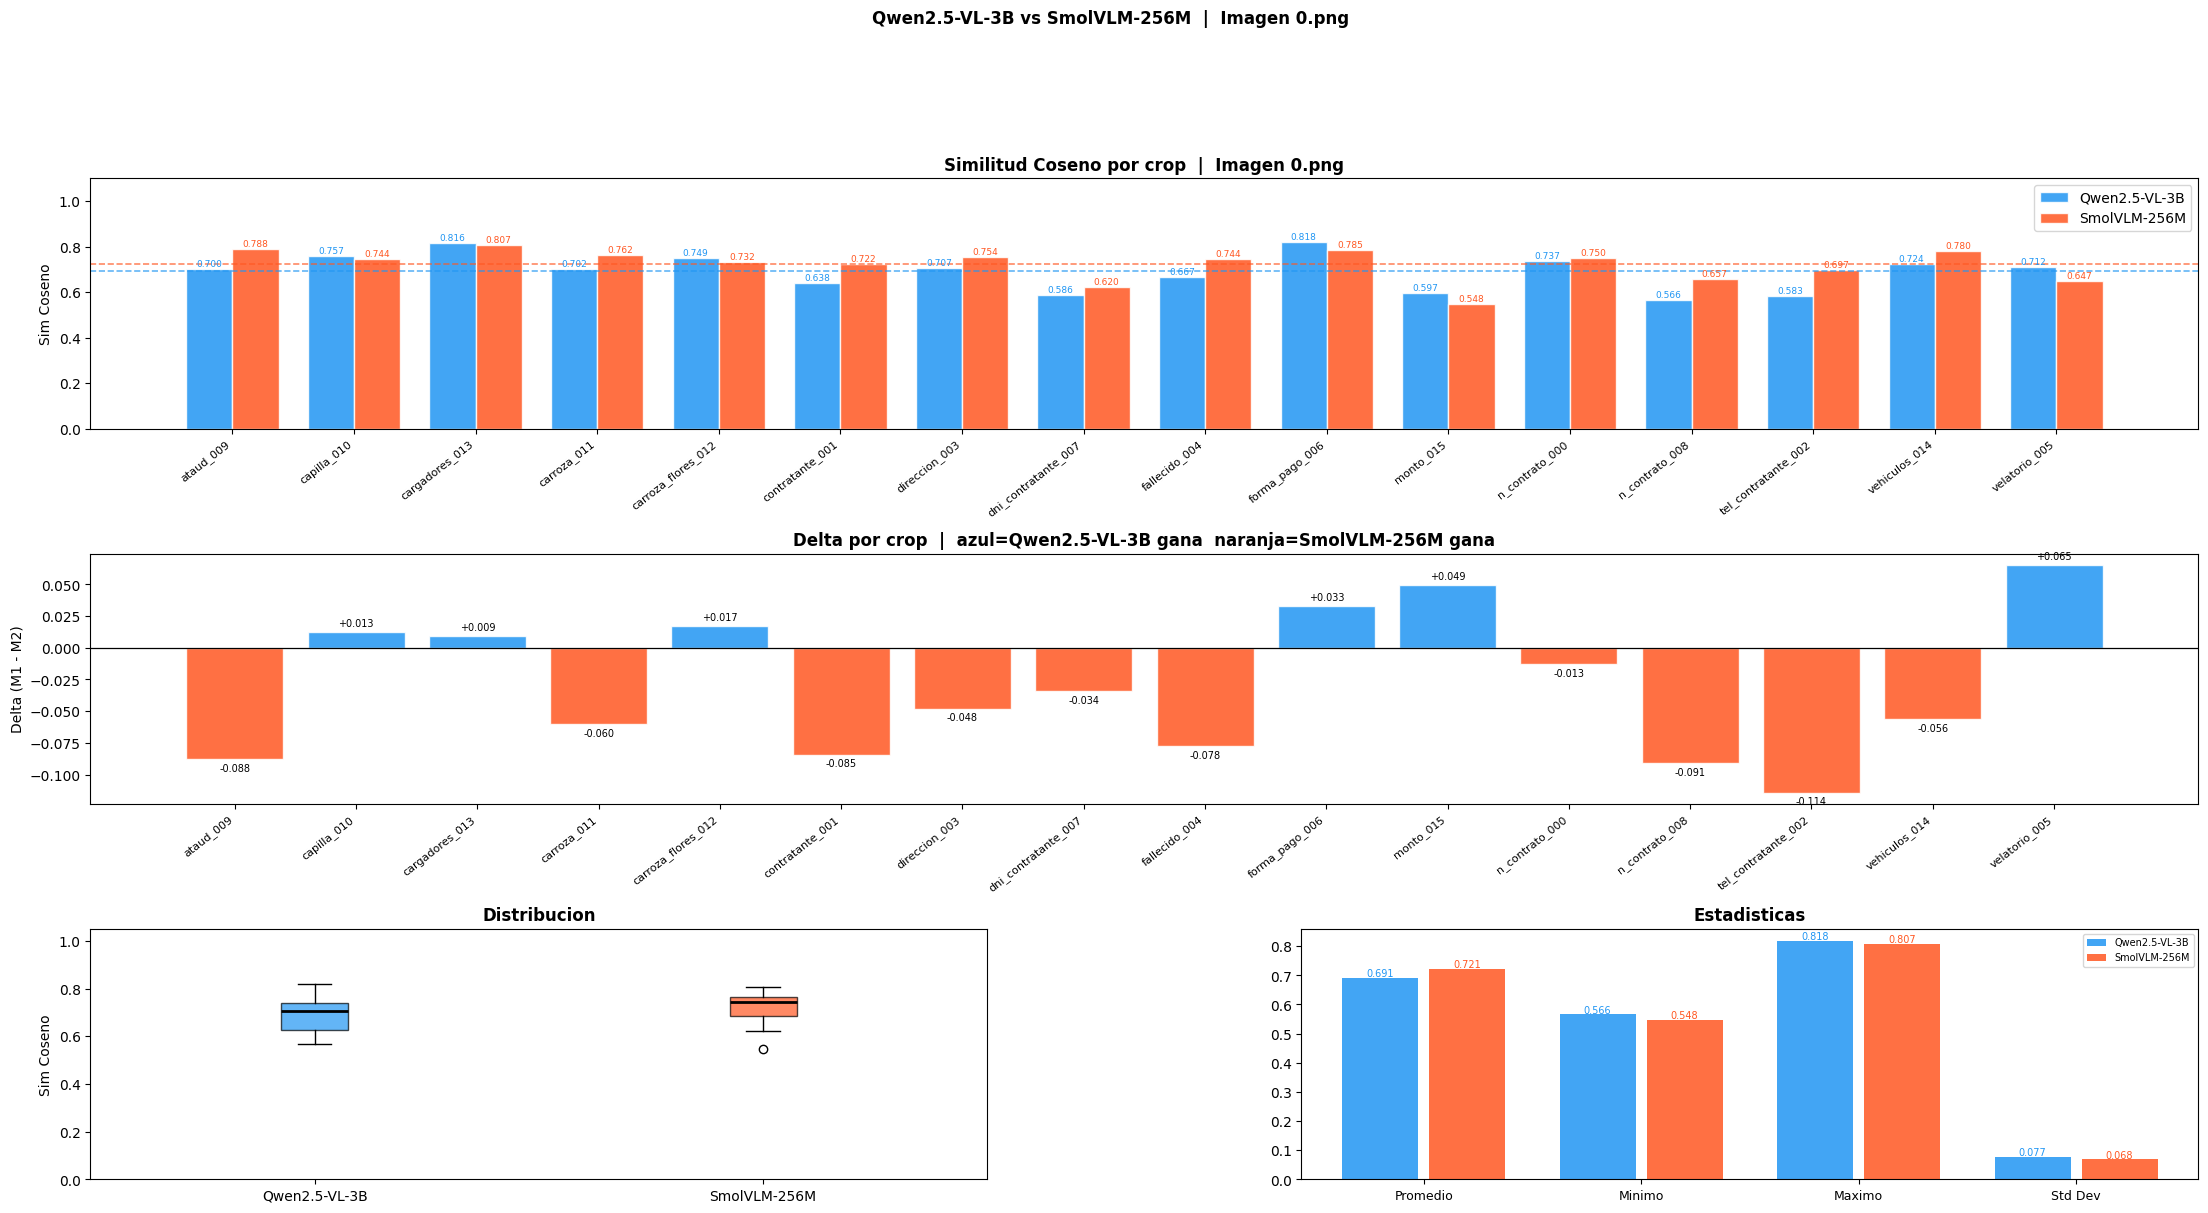

Guardado: C:\Users\fabri\OneDrive\Desktop\UPAO\Funeraria_Inventario_Inteligente\results\model_comparison\comparison_img0.png


In [12]:
C1, C2 = "#2196F3", "#FF5722"

def plot_comparison(n):
    sub    = df[df["imagen"] == n].reset_index(drop=True)
    labels = [l[:20] for l in sub["crop_label"]]
    s1     = sub[f"sim_{ALIAS_1}"].values
    s2     = sub[f"sim_{ALIAS_2}"].values
    deltas = sub["delta"].values
    x, w   = np.arange(len(labels)), 0.38

    fig = plt.figure(figsize=(max(12, len(labels)*1.7), 13))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.35)

    ax1 = fig.add_subplot(gs[0, :])
    b1  = ax1.bar(x - w/2, s1, w, label=ALIAS_1, color=C1, alpha=0.85, edgecolor="white")
    b2  = ax1.bar(x + w/2, s2, w, label=ALIAS_2, color=C2, alpha=0.85, edgecolor="white")
    ax1.axhline(s1.mean(), color=C1, ls="--", lw=1.2, alpha=0.7)
    ax1.axhline(s2.mean(), color=C2, ls="--", lw=1.2, alpha=0.7)
    ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=38, ha="right", fontsize=8)
    ax1.set_ylabel("Sim Coseno"); ax1.set_ylim(0, 1.1)
    ax1.set_title(f"Similitud Coseno por crop  |  Imagen {n}.png", fontweight="bold")
    ax1.legend(loc="upper right")
    for bar in b1:
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.012,
                 f"{bar.get_height():.3f}", ha="center", fontsize=6.5, color=C1)
    for bar in b2:
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.012,
                 f"{bar.get_height():.3f}", ha="center", fontsize=6.5, color=C2)

    ax2 = fig.add_subplot(gs[1, :])
    ax2.bar(x, deltas, color=[C1 if d >= 0 else C2 for d in deltas], alpha=0.85, edgecolor="white")
    ax2.axhline(0, color="black", lw=0.9)
    ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=38, ha="right", fontsize=8)
    ax2.set_ylabel("Delta (M1 - M2)")
    ax2.set_title(f"Delta por crop  |  azul={ALIAS_1} gana  naranja={ALIAS_2} gana", fontweight="bold")
    for xi, d in zip(x, deltas):
        va = "bottom" if d >= 0 else "top"
        ax2.text(xi, d + (0.003 if d >= 0 else -0.003), f"{d:+.3f}", ha="center", va=va, fontsize=7)

    ax3 = fig.add_subplot(gs[2, 0])
    bp  = ax3.boxplot([s1, s2], labels=[ALIAS_1, ALIAS_2], patch_artist=True, notch=False,
                      medianprops=dict(color="black", lw=2))
    for patch, col in zip(bp["boxes"], [C1, C2]):
        patch.set_facecolor(col); patch.set_alpha(0.7)
    ax3.set_ylim(0, 1.05); ax3.set_ylabel("Sim Coseno")
    ax3.set_title("Distribucion", fontweight="bold")

    ax4   = fig.add_subplot(gs[2, 1])
    slbls = ["Promedio", "Minimo", "Maximo", "Std Dev"]
    v1    = [s1.mean(), s1.min(), s1.max(), s1.std()]
    v2    = [s2.mean(), s2.min(), s2.max(), s2.std()]
    xi2   = np.arange(len(slbls))
    ax4.bar(xi2 - 0.2, v1, 0.35, label=ALIAS_1, color=C1, alpha=0.85)
    ax4.bar(xi2 + 0.2, v2, 0.35, label=ALIAS_2, color=C2, alpha=0.85)
    ax4.set_xticks(xi2); ax4.set_xticklabels(slbls, fontsize=9)
    ax4.set_title("Estadisticas", fontweight="bold"); ax4.legend(fontsize=7)
    for i_s, (a, b_v) in enumerate(zip(v1, v2)):
        ax4.text(i_s-0.2, a+0.005, f"{a:.3f}", ha="center", fontsize=7, color=C1)
        ax4.text(i_s+0.2, b_v+0.005, f"{b_v:.3f}", ha="center", fontsize=7, color=C2)

    plt.suptitle(f"{ALIAS_1} vs {ALIAS_2}  |  Imagen {n}.png", fontsize=12, fontweight="bold", y=1.01)
    path = RESULTS_DIR / f"comparison_img{n}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    print(f"Guardado: {path}")

for n in SELECTION:
    plot_comparison(n)

12. Heatmap

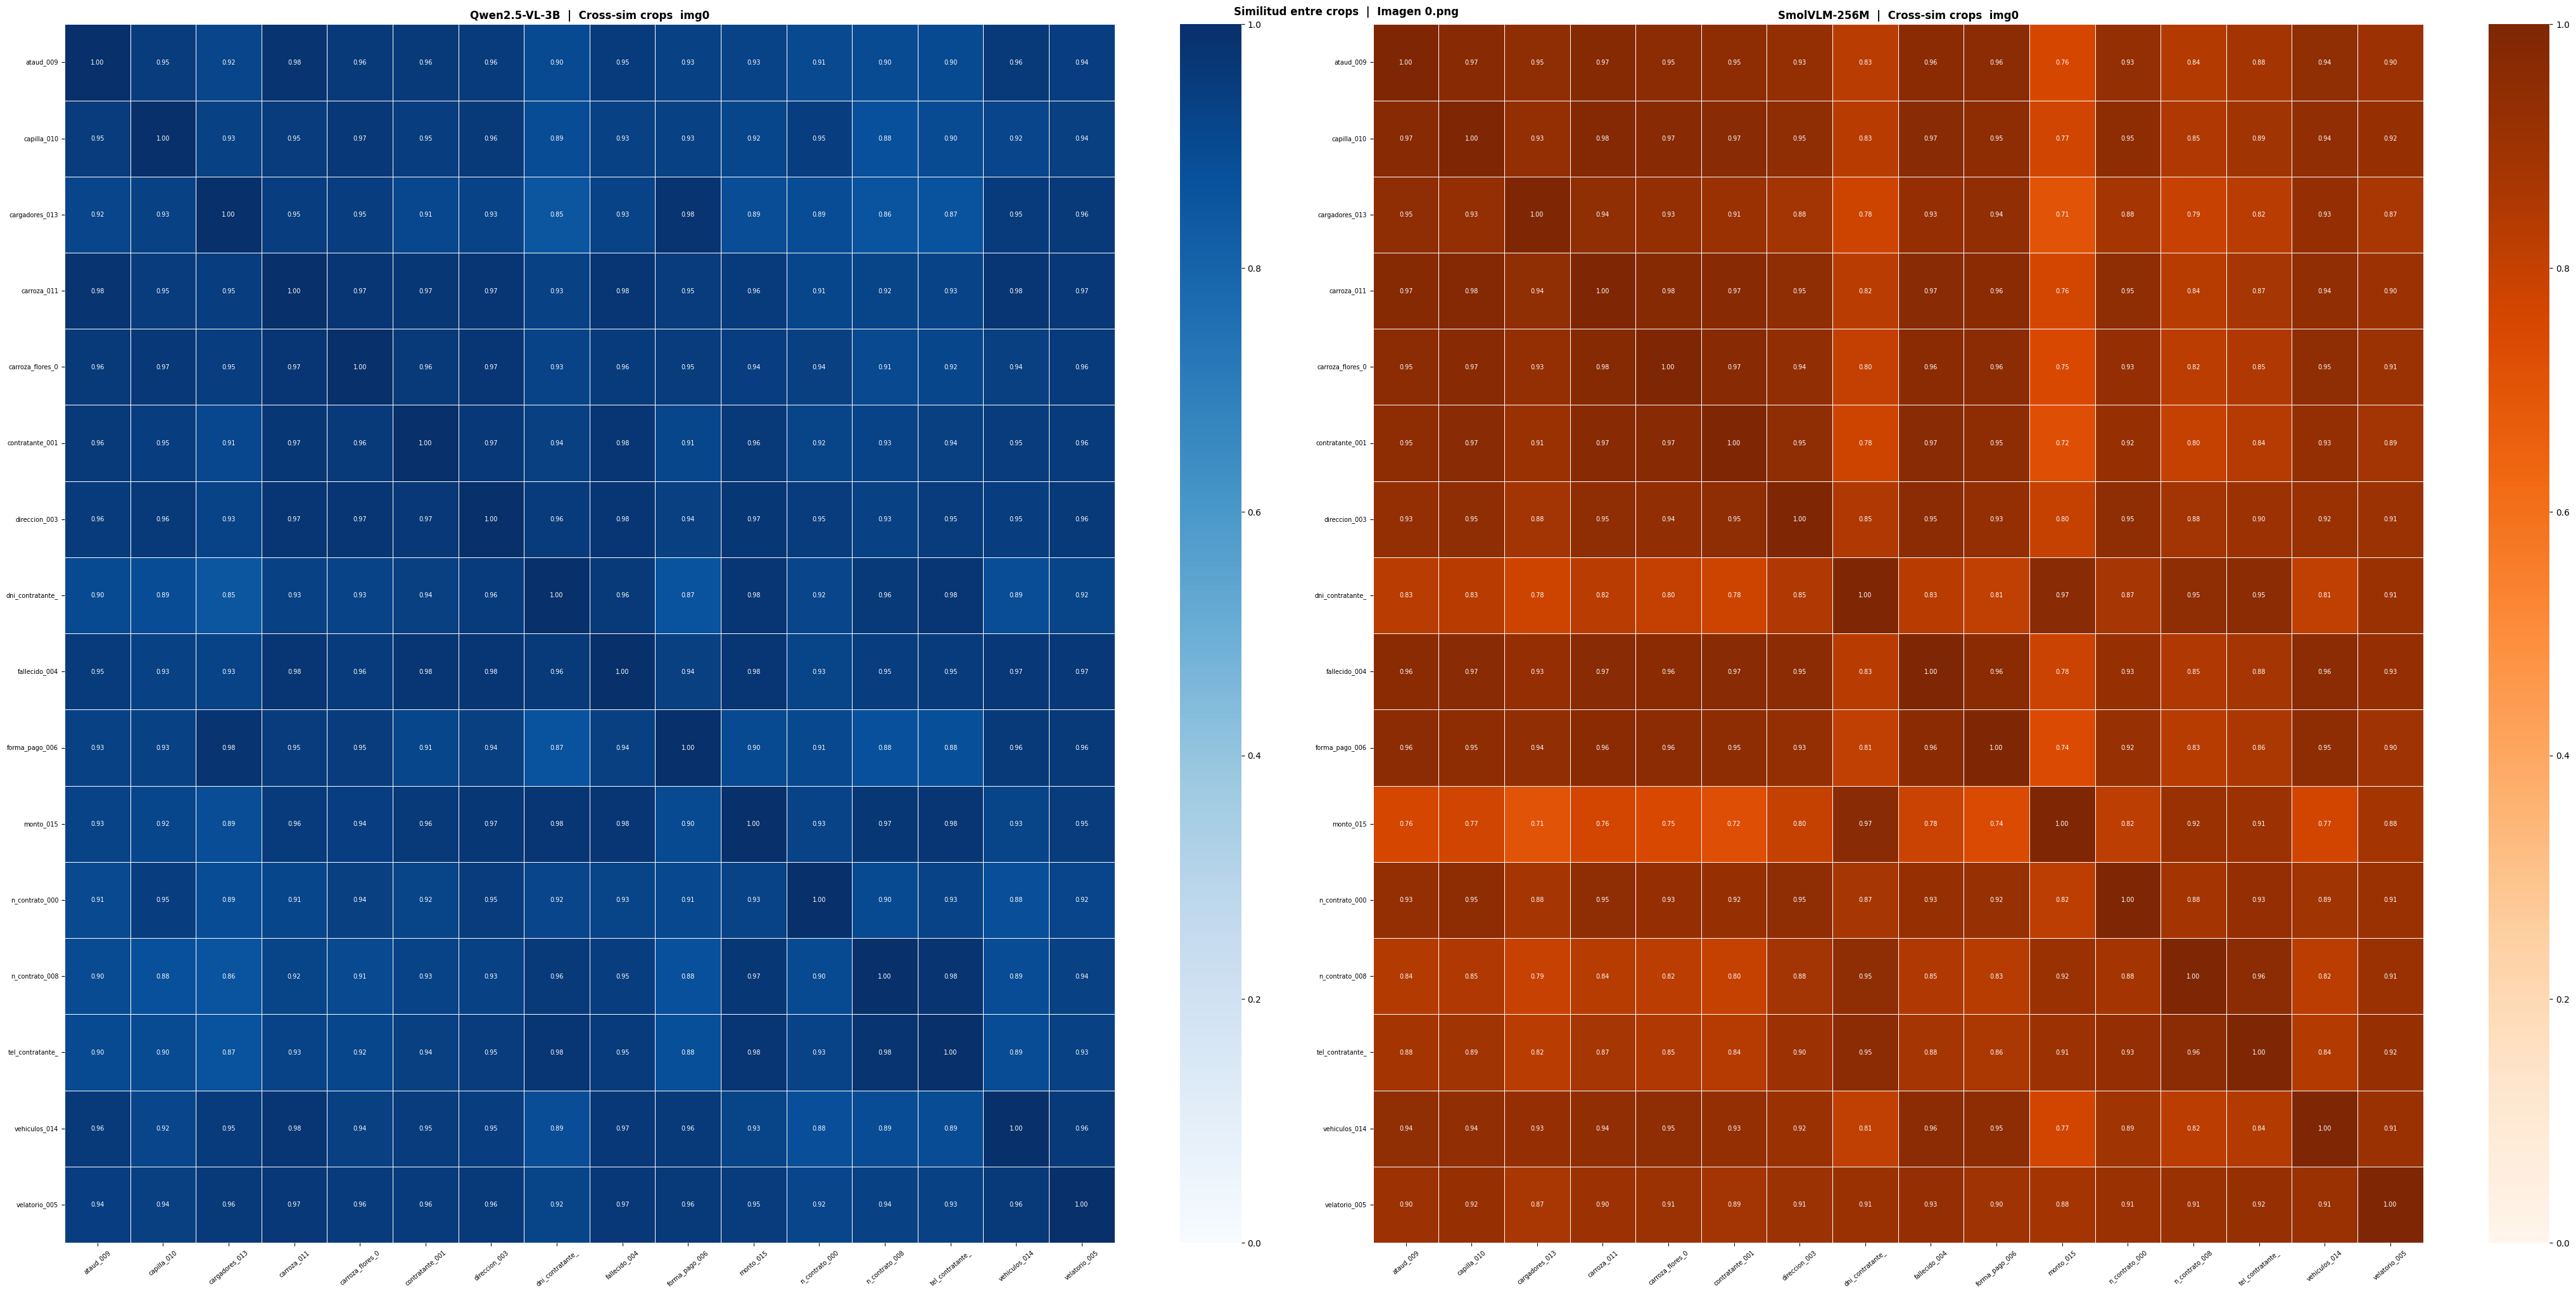

Guardado: C:\Users\fabri\OneDrive\Desktop\UPAO\Funeraria_Inventario_Inteligente\results\model_comparison\heatmap_img0.png


In [13]:
def plot_heatmap(n):
    r1, r2 = results_m1[n], results_m2[n]
    labels = [nm[:16] for nm in r1["names"]]
    mat1   = sk_cosine(np.array(r1["crops"]))
    mat2   = sk_cosine(np.array(r2["crops"]))
    sz     = max(8, len(labels) * 1.3)

    fig, axes = plt.subplots(1, 2, figsize=(sz * 2 + 1, sz))
    for ax, mat, alias, cmap in [
        (axes[0], mat1, ALIAS_1, "Blues"),
        (axes[1], mat2, ALIAS_2, "Oranges"),
    ]:
        sns.heatmap(mat, ax=ax, cmap=cmap, annot=True, fmt=".2f",
                    xticklabels=labels, yticklabels=labels,
                    vmin=0, vmax=1, linewidths=0.4, annot_kws={"size": 7})
        ax.set_title(f"{alias}  |  Cross-sim crops  img{n}", fontweight="bold")
        ax.tick_params(axis="x", rotation=40, labelsize=7)
        ax.tick_params(axis="y", rotation=0,  labelsize=7)

    plt.suptitle(f"Similitud entre crops  |  Imagen {n}.png", fontsize=12, fontweight="bold")
    plt.tight_layout()
    path = RESULTS_DIR / f"heatmap_img{n}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    print(f"Guardado: {path}")

for n in SELECTION:
    if len(results_m1[n]["crops"]) > 1:
        plot_heatmap(n)
    else:
        print(f"img{n}: solo 1 crop, heatmap omitido")

13. Veredicto y JSON

In [14]:
sep = "=" * 62
global_json = {
    "timestamp": datetime.now().isoformat(),
    "prompt": PROMPT,
    "imagenes": [],
    "ganador_global": None,
}

g1_wins = 0
g2_wins = 0

print(sep)
print("  VEREDICTO POR IMAGEN")
print(sep)

for n in SELECTION:
    sub = df[df["imagen"] == n]
    s1  = sub[f"sim_{ALIAS_1}"].values
    s2  = sub[f"sim_{ALIAS_2}"].values
    pm1, pm2 = s1.mean(), s2.mean()
    win    = ALIAS_1 if pm1 >= pm2 else ALIAS_2
    margin = abs(pm1 - pm2)
    if win == ALIAS_1: g1_wins += 1
    else: g2_wins += 1
    cw1 = int((sub["winner"] == ALIAS_1).sum())
    cw2 = int((sub["winner"] == ALIAS_2).sum())

    print(f"\n  Imagen {n}.png  ({len(s1)} crops)")
    print(f"  {ALIAS_1:<26}  prom={pm1:.4f}  std={s1.std():.4f}  crops_won={cw1}")
    print(f"  {ALIAS_2:<26}  prom={pm2:.4f}  std={s2.std():.4f}  crops_won={cw2}")
    print(f"  GANADOR img{n}: {win}  (margen={margin:.4f})")

    global_json["imagenes"].append({
        "imagen": int(n), "n_crops": int(len(s1)),
        "ganador": win, "margen": round(margin, 6),
        ALIAS_1: {
            "sim_prom": round(pm1, 4), "sim_std": round(s1.std(), 4),
            "sim_min": round(s1.min(), 4), "sim_max": round(s1.max(), 4),
            "crops_ganados": cw1,
            "per_crop": dict(zip(sub["crop_label"].tolist(), [round(v,4) for v in s1.tolist()])),
        },
        ALIAS_2: {
            "sim_prom": round(pm2, 4), "sim_std": round(s2.std(), 4),
            "sim_min": round(s2.min(), 4), "sim_max": round(s2.max(), 4),
            "crops_ganados": cw2,
            "per_crop": dict(zip(sub["crop_label"].tolist(), [round(v,4) for v in s2.tolist()])),
        },
    })

gm1 = df[f"sim_{ALIAS_1}"].mean()
gm2 = df[f"sim_{ALIAS_2}"].mean()
gw  = ALIAS_1 if gm1 >= gm2 else ALIAS_2
global_json["ganador_global"] = {
    "alias": gw, "hf_id": MODELS[gw],
    "sim_prom_total": round(max(gm1, gm2), 4),
    "margen_global": round(abs(gm1 - gm2), 4),
    "imagenes_ganadas": g1_wins if gw == ALIAS_1 else g2_wins,
    "total_imagenes": len(SELECTION),
}

print(); print(sep)
print(f"  GANADOR GLOBAL : {gw}")
print(f"  HF ID          : {MODELS[gw]}")
print(f"  Sim prom total : {max(gm1,gm2):.4f}  (rival: {min(gm1,gm2):.4f})")
print(f"  Imagenes won   : {global_json['ganador_global']['imagenes_ganadas']}/{len(SELECTION)}")
print(sep)

json_path = RESULTS_DIR / "results_full.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(global_json, f, ensure_ascii=False, indent=2)

print(f"\nArchivos en: {RESULTS_DIR.resolve()}")
for fp in sorted(RESULTS_DIR.iterdir()):
    print(f"  {fp.name}")

  VEREDICTO POR IMAGEN

  Imagen 0.png  (16 crops)
  Qwen2.5-VL-3B               prom=0.6911  std=0.0767  crops_won=6
  SmolVLM-256M                prom=0.7212  std=0.0683  crops_won=10
  GANADOR img0: SmolVLM-256M  (margen=0.0300)

  GANADOR GLOBAL : SmolVLM-256M
  HF ID          : HuggingFaceTB/SmolVLM-256M-Instruct
  Sim prom total : 0.7212  (rival: 0.6911)
  Imagenes won   : 1/1

Archivos en: C:\Users\fabri\OneDrive\Desktop\UPAO\Funeraria_Inventario_Inteligente\results\model_comparison
  comparison_img0.png
  cosine_similarity.csv
  full_img_preprocessed_0.jpg
  heatmap_img0.png
  overview_img0.png
  results_full.json


14.  Resumen multi-imagen

In [15]:
if len(SELECTION) > 1:
    imgs  = list(SELECTION.keys())
    m1avg = [df[df["imagen"]==n][f"sim_{ALIAS_1}"].mean() for n in imgs]
    m2avg = [df[df["imagen"]==n][f"sim_{ALIAS_2}"].mean() for n in imgs]

    x = np.arange(len(imgs))
    fig, ax = plt.subplots(figsize=(max(8, len(imgs)*2.2), 5))
    ax.bar(x - 0.2, m1avg, 0.35, label=ALIAS_1, color=C1, alpha=0.85)
    ax.bar(x + 0.2, m2avg, 0.35, label=ALIAS_2, color=C2, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels([f"img {n}" for n in imgs], fontsize=10)
    ax.set_ylabel("Sim Coseno promedio")
    ax.set_title("Comparacion promedio por imagen", fontweight="bold")
    ax.set_ylim(0, 1.05); ax.legend()
    for i_p, (a, b) in enumerate(zip(m1avg, m2avg)):
        ax.text(i_p-0.2, a+0.012, f"{a:.3f}", ha="center", fontsize=8, color=C1)
        ax.text(i_p+0.2, b+0.012, f"{b:.3f}", ha="center", fontsize=8, color=C2)

    sp = RESULTS_DIR / "summary_all_images.png"
    plt.savefig(sp, dpi=150, bbox_inches="tight"); plt.show(); plt.close()
    print(f"Guardado: {sp}")
else:
    print("Solo 1 imagen — grafico multi-imagen omitido.")

Solo 1 imagen — grafico multi-imagen omitido.
